In [13]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
sns.set_theme(style="whitegrid")
plt.rcParams["font.family"] = "sans-serif"

In [14]:
account=pd.read_csv(r"..\cleanData\clean_account.csv", sep=";")
account.rename(columns={"date": "Account_date"}, inplace=True)
account["district_id"] = account["district_id"].astype(str)
account["account_id"] = account["account_id"].astype(str)
account["Account_date"] = pd.to_datetime(
    account["Account_date"], format="mixed", errors="coerce"
)
# Extract year for EDA
account["account_year"] = account["Account_date"].dt.year

In [15]:
account.head()

,account_id,district_id,frequency,Account_date,account_year
0,576,55,monthly,1993-01-01,1993
1,3818,74,monthly,1993-01-01,1993
2,704,55,monthly,1993-01-01,1993
3,2378,16,monthly,1993-01-01,1993
4,2632,24,monthly,1993-01-02,1993


In [16]:
reference_date = account['Account_date'].max()

# A. Account Tenure & Vintage
account['account_age_days'] = (reference_date - account['Account_date']).dt.days
account['account_age_months'] = (account['account_age_days'] / 30.44).round(1)

account['vintage_year'] = account['Account_date'].dt.year
account['vintage_quarter'] = account['Account_date'].dt.to_period('Q')

# B. Account Recency Flags
account['is_new_account'] = (account['account_age_days'] <= 180).astype(int)
account['is_mature_account'] = (account['account_age_days'] >= 730).astype(int)

# C. District Account Density (Frequency Encoding)
district_counts = account['district_id'].value_counts().to_dict()
account['district_account_density'] = account['district_id'].map(district_counts)
account['district_account_share'] = account['district_account_density'] / len(
    account
)


# ==========================================
# 2. PREPROCESSING & ENCODING
# ==========================================

# Ensure ID columns are treated as strings
account['account_id'] = account['account_id'].astype(str)
account['district_id'] = account['district_id'].astype(str)

# One-Hot Encoding for vintage cohorts
vintage_dummies = pd.get_dummies(
    account['vintage_year'], prefix='vintage', drop_first=True
)
account = pd.concat([account, vintage_dummies], axis=1)


# ==========================================
# 3. HELPER FUNCTION FOR DOWNSTREAM JOINS
# ==========================================


def calculate_tenure_at_loan(loan_df, account_df):
  """Calculates customer relationship age at the exact moment of loan origination."""
  # Ensure date types match before merging
  loan_df['loan_date'] = pd.to_datetime(loan_df['loan_date'])
  account_df['Account_date'] = pd.to_datetime(account_df['Account_date'])

  # Convert keys to string for clean join
  loan_df['account_id'] = loan_df['account_id'].astype(str)
  account_df['account_id'] = account_df['account_id'].astype(str)

  merged = loan_df.merge(
      account_df[['account_id', 'Account_date']], on='account_id', how='left'
  )

  merged['tenure_at_loan_days'] = (
      merged['loan_date'] - merged['Account_date']
  ).dt.days
  merged['tenure_at_loan_months'] = (
      merged['tenure_at_loan_days'] / 30.44
  ).round(1)

  return merged


# ==========================================
# VERIFICATION
# ==========================================
print('Account DataFrame shape:', account.shape)
account.head()

Account DataFrame shape: (4500, 17)


,account_id,district_id,frequency,Account_date,account_year,account_age_days,account_age_months,vintage_year,vintage_quarter,is_new_account,is_mature_account,district_account_density,district_account_share,vintage_1994,vintage_1995,vintage_1996,vintage_1997
0,576,55,monthly,1993-01-01,1993,1823,59.9,1993,1993Q1,0,1,53,0.011778,False,False,False,False
1,3818,74,monthly,1993-01-01,1993,1823,59.9,1993,1993Q1,0,1,135,0.030000,False,False,False,False
2,704,55,monthly,1993-01-01,1993,1823,59.9,1993,1993Q1,0,1,53,0.011778,False,False,False,False
3,2378,16,monthly,1993-01-01,1993,1823,59.9,1993,1993Q1,0,1,52,0.011556,False,False,False,False
4,2632,24,monthly,1993-01-02,1993,1822,59.9,1993,1993Q1,0,1,42,0.009333,False,False,False,False


In [17]:
# List of newly engineered columns to drop
cols_to_drop = [
    'account_age_days',
    'vintage_year',
    'vintage_quarter',
    'is_mature_account',
    'district_account_density',
    'district_account_share'
]

# Include vintage one-hot encoded dummy columns (e.g., vintage_1994, vintage_1995, etc.) if created
vintage_dummy_cols = [col for col in account.columns if col.startswith('vintage_')]
cols_to_drop.extend(vintage_dummy_cols)

# Drop the columns from the account DataFrame inplace
account.drop(columns=[col for col in cols_to_drop if col in account.columns], inplace=True)

# Verification
print("Remaining columns in account table:")
print(account.columns.tolist())
account.head()

Remaining columns in account table:
['account_id', 'district_id', 'frequency', 'Account_date', 'account_year', 'account_age_months', 'is_new_account']


,account_id,district_id,frequency,Account_date,account_year,account_age_months,is_new_account
0,576,55,monthly,1993-01-01,1993,59.9,0
1,3818,74,monthly,1993-01-01,1993,59.9,0
2,704,55,monthly,1993-01-01,1993,59.9,0
3,2378,16,monthly,1993-01-01,1993,59.9,0
4,2632,24,monthly,1993-01-02,1993,59.9,0


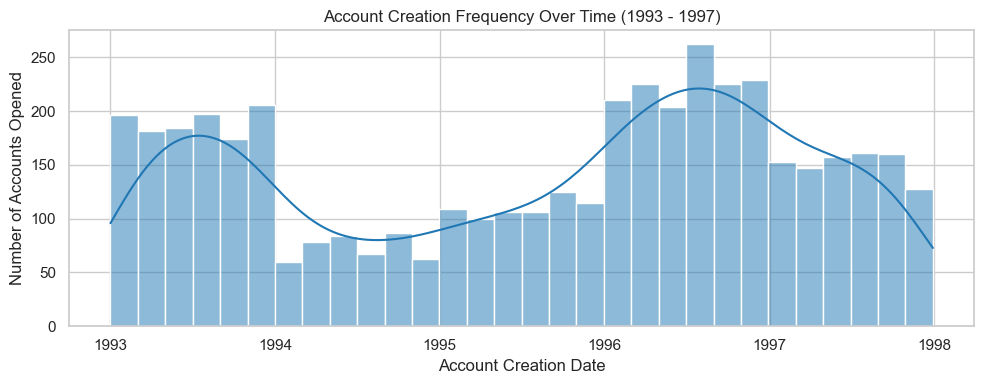

In [18]:
plt.figure(figsize=(10, 4))
sns.histplot(
    data=account, x="Account_date", bins=30, kde=True, color="#1f77b4"
)
plt.title("Account Creation Frequency Over Time (1993 - 1997)")
plt.xlabel("Account Creation Date")
plt.ylabel("Number of Accounts Opened")
plt.tight_layout()
plt.show()

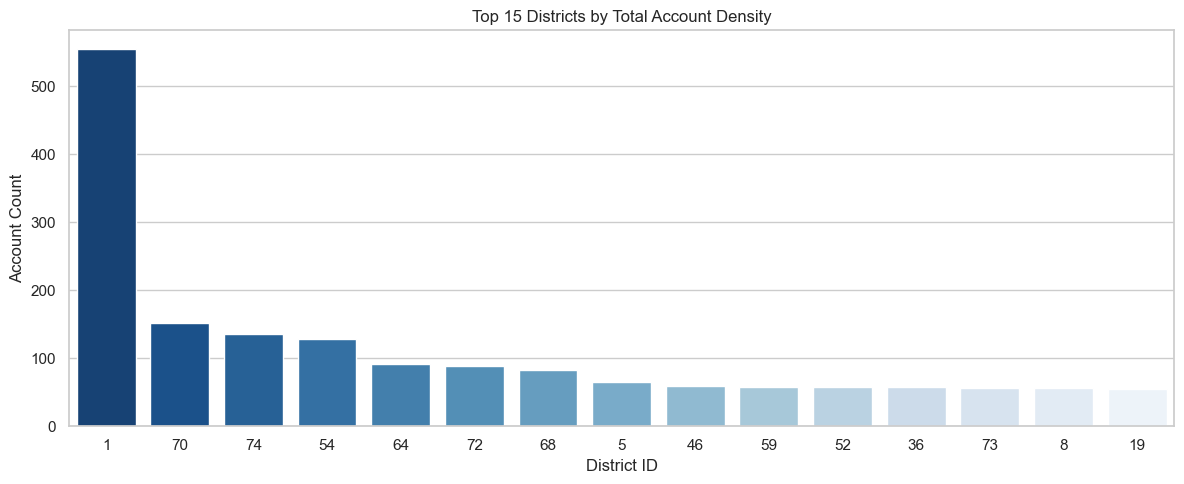

In [19]:
plt.figure(figsize=(12, 5))
top_districts = account["district_id"].value_counts().head(15)
sns.barplot(
    x=top_districts.index,
    y=top_districts.values,
    palette="Blues_r",
    order=top_districts.index,
)
plt.title("Top 15 Districts by Total Account Density")
plt.xlabel("District ID")
plt.ylabel("Account Count")
plt.tight_layout()
plt.show()

In [20]:
account["frequency"].value_counts()

frequency
monthly              4167
weekly                240
after_transaction      93
Name: count, dtype: int64

In [22]:
import os
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

# 1. Load clean datasets
loans = pd.read_csv('../cleanData/clean_loan.csv', sep=';')
accounts = pd.read_csv('../cleanData/clean_account.csv', sep=';')

# 2. Standardize keys as strings
loans['account_id'] = loans['account_id'].astype(str).str.strip()
loans['loan_id'] = loans['loan_id'].astype(str).str.strip()
accounts['account_id'] = accounts['account_id'].astype(str).str.strip()

# 3. Parse datetime objects
loans['loan_date'] = pd.to_datetime(loans['date'])
accounts['account_created_date'] = pd.to_datetime(accounts['date'])

# 4. Merge account metadata onto loan spine
loan_accounts = loans[['loan_id', 'account_id', 'loan_date', 'target']].merge(
    accounts[['account_id', 'frequency', 'account_created_date', 'district_id']],
    on='account_id',
    how='left'
)

# 5. Temporal audit: Calculate tenure days prior to loan
loan_accounts['account_tenure_days_before_loan'] = (
    loan_accounts['loan_date'] - loan_accounts['account_created_date']
).dt.days

# 6. Verify strictly pre-loan accounts
pre_loan_valid = loan_accounts['account_created_date'] < loan_accounts['loan_date']
print(f"Total loans: {len(loan_accounts)}")
print(f"Accounts opened strictly BEFORE loan date: {pre_loan_valid.sum()} / {len(loan_accounts)}")
print(f"Accounts opened ON or AFTER loan date:     {(~pre_loan_valid).sum()}")

# Tenure in months before loan
loan_accounts['account_tenure_months_before_loan'] = (
    loan_accounts['account_tenure_days_before_loan'] / 30.44
).round(1)

# One-hot encode statement issuance frequency
freq_dummies = pd.get_dummies(
    loan_accounts['frequency'], 
    prefix='freq', 
    drop_first=False
).astype(int)

loan_accounts = pd.concat([loan_accounts, freq_dummies], axis=1)
loan_accounts.head()

Total loans: 682
Accounts opened strictly BEFORE loan date: 682 / 682
Accounts opened ON or AFTER loan date:     0


,loan_id,account_id,loan_date,target,frequency,account_created_date,district_id,account_tenure_days_before_loan,account_tenure_months_before_loan,freq_after_transaction,freq_monthly,freq_weekly
0,5314,1787,1993-07-05,1,weekly,1993-03-22,30,105,3.4,0,0,1
1,5316,1801,1993-07-11,0,monthly,1993-02-13,46,148,4.9,0,1,0
2,6863,9188,1993-07-28,0,monthly,1993-02-08,45,170,5.6,0,1,0
3,5325,1843,1993-08-03,0,monthly,1993-01-30,12,185,6.1,0,1,0
4,7240,11013,1993-09-06,0,weekly,1993-02-14,1,204,6.7,0,0,1


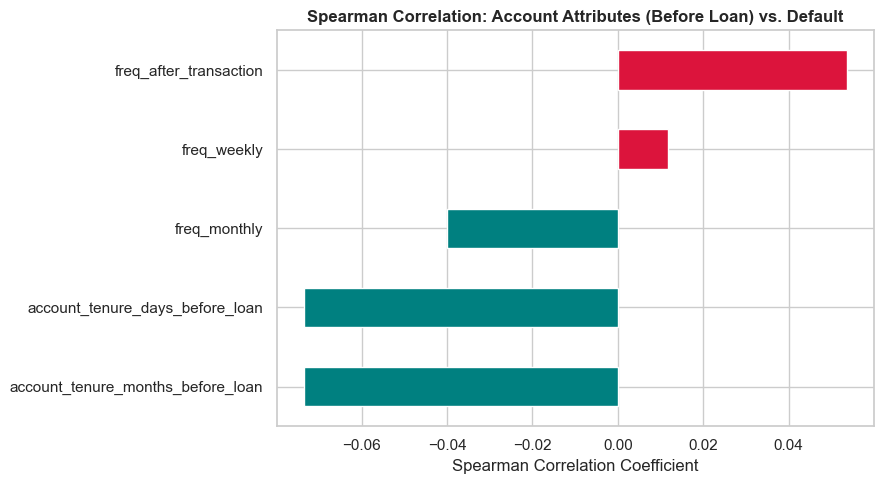


--- Exact Correlation Values ---
account_tenure_months_before_loan   -0.073551
account_tenure_days_before_loan     -0.073407
freq_monthly                        -0.039912
freq_weekly                          0.011774
freq_after_transaction               0.053633
target                               1.000000
Name: target, dtype: float64


In [23]:
# 1. Select numeric features
numeric_cols = [
    'account_tenure_days_before_loan',
    'account_tenure_months_before_loan'
] + [c for c in loan_accounts.columns if c.startswith('freq_')] + ['target']

account_corr = loan_accounts[numeric_cols].corr(method='spearman')['target'].sort_values()

# 2. Plot horizontal correlation bar chart
plt.figure(figsize=(9, 5))
account_corr.drop('target', errors='ignore').plot(
    kind='barh',
    color=np.where(account_corr.drop('target', errors='ignore') > 0, 'crimson', 'teal')
)
plt.title('Spearman Correlation: Account Attributes (Before Loan) vs. Default', fontsize=12, fontweight='bold')
plt.xlabel('Spearman Correlation Coefficient')
plt.tight_layout()
plt.show()

print("\n--- Exact Correlation Values ---")
print(account_corr)

In [ ]:
# import os
# import pandas as pd

# # ==========================================
# # CONFIGURATION (Update this for each notebook)
# # ==========================================
# # Example names: 'features_loan.csv', 'features_district.csv', 
# #                'features_orders.csv', 'features_transaction.csv'
# OUTPUT_FILENAME = "feature_client.csv"

# # List the specific columns you want in your final feature matrix.
# # Set to None if your dataframe is already cleaned and contains ONLY features (+ target if in loan notebook)
# FEATURE_COLS = ['has_co_signer']  # e.g., ['amount', 'duration', 'payments', 'target']

# # ==========================================
# # EXPORT LOGIC
# # ==========================================
# df_export = loan_clients.copy()

# # 1. Standardize loan_id as the primary key index
# if "loan_id" in df_export.columns:
#     df_export["loan_id"] = df_export["loan_id"].astype(str)
#     df_export.set_index("loan_id", inplace=True)
# elif df_export.index.name != "loan_id":
#     df_export.index = df_export.index.astype(str)
#     df_export.index.name = "loan_id"

# # 2. Filter features if a column list is specified
# if FEATURE_COLS is not None:
#     valid_cols = [c for c in FEATURE_COLS if c in df_export.columns]
#     df_export = df_export[valid_cols]

# # 3. Ensure the destination directory exists
# output_dir = "../modelData"
# os.makedirs(output_dir, exist_ok=True)
# output_path = os.path.join(output_dir, OUTPUT_FILENAME)

# # 4. Save to CSV
# df_export.to_csv(output_path)

# # 5. Validation printout
# print("=" * 45)
# print(f" Saved successfully to: {output_path}")
# print(f" Total Rows (Loans):   {df_export.shape[0]}")
# print(f" Total Feature Cols:   {df_export.shape[1]}")
# print(f" Missing Values (NaN): {df_export.isna().sum().sum()}")
# print("=" * 45)